# San Francisco movie scene

This notebook presents the journey we took to build the [San Francisco Film website](https://www.omdbapi.com/)

---

### Contents

| # | Section | Description |
|---|---------|-------------|
| 1 | [Motivation](#Motivation) | Data description and UX goal |
| 2 | [Basic Stats](#Basic-Stats) | Data preprocessing and exploratory data analysis |
| 3 | [Data Analysis](#Data-Analysis) | Data processing, data analysis and sentiment analysis used |
| 4 | [Genre](#Genre) | Smth here |
| 5 | [Visualization](#Visualization) | Smth here |
| 6 | [Discussion](#Discussion) | Smth here |
| 7 | [Contributions](#Contributions) | Team contributions |
| 8 | [Use of AI](#Use-of-AI) | How AI was used |
| 9 | [References](#References) | List of references used |
| 10 | [Appendix](#Appendix) | Additional graphs and code for further details |

## Motivation

As people who like movies and data, we decided to explore the San Francisco filming history to see if there were patterns or information that could tell us what makes a movie succesful. There are a lot of factors that can influence a movie into becoming a hit, so we decided to explore some of them and guide users through our journey, giving them the insights we got at the same time they have the opportunity to explore by themselves.

---

### What is your dataset?

We built our own dataset by combining two sources:
- The Film Location database of the open data portal of San Francisco ([Open SF](https://data.sfgov.org/Culture-and-Recreation/Film-Locations-in-San-Francisco/yitu-d5am/about_data))<sup><a href="#ref1">[1]</a></sup>, which contains basic information about the films that have been filmed in San Francisco, as well as geographical data to know where they were filmed.
- [OMDb API](https://www.omdbapi.com/)<sup><a href="#ref2">[2]</a></sup> for obtaining more of the films information. It is a free alternative to get the information presented in the IMDb website.

---

### Why did you choose this/these particular dataset(s)?

Our base dataset was the Film Location database of San Francisco, which was chosen due to the geographical dimension it adds to the movie information. Movie datasets tend to have limited information regarding the locations at which their filming took place, but this dataset has a bigger granularity, allowing to see the neighborhoods, places and coordinates of the filmings.

That dataset had a good detail in geographical terms, but was limited in terms of information presented about the movie. Therefore, we decided to complement it with IMDb information, allowing us to make a more complete analysis. However, it costs money to access the IMDb complete database, so we took an alternative through the OMDb API, which allowed us to fetch many of the same IMDb data by free.

---

### What was your goal for the end user's experience?

Our goal is to allow users to learn and explore about films in two not so common dimensions: geographical and emotional. We want them to realize how a different take into films data can reveal valuable information regarding succesful movies. 

As these topics can be complex for users that are not familiar to data analysis, we created a dynamic website which guides the users through it, allowing them to learn and comprehend the information without having to learn a lot of text.

---

## Basic Stats

### Write about your choices in data cleaning and preprocessing

The original San Francisco dataset contains 2214 rows and 18 columns. Each row contains information of a filming location, so a single title could have more than one related row of information. Considering this, we decided to extract the unique titles and release year (in case two different movies had the same name), manually search all of them and mark them in case they had a different name in IMDb (OMDb). To simplify this process, we did it on a separate file. The way we marked them was by adding a new IMDb ID column to the separated file. If they were not found they were flagged to delete. 16 rows (7 Unique Titles) were deleted following that rule.

As the OMDb API retrieval needs to match either the exact title or the IMDb ID, we used both columns of the dataset to retrieve the information. We merged the separated file with the San Francisco filming dataset, and from there, we performed the information retrieval. 156 unique titles were searched by using the IMDb ID (1224 rows), while 189 unique titles were searched by using the title (1020 rows). For the OMDb API information retrieval, we decided to fetch the following information:

| Field | API Key | Category |
|-------|---------|----------|
| `imdb_id` | `imdbID` | Identity |
| `title` | `Title` | Identity |
| `year` | `Year` | Identity |
| `kind` | `Type` | Identity |
| `genres` | `Genre` | Content |
| `plot` | `Plot` | Content |
| `language` | `Language` | Content |
| `country` | `Country` | Content |
| `certificates` | `Rated` | Content |
| `runtime` | `Runtime` | Content |
| `awards` | `Awards` | Content |
| `directors` | `Director` | People |
| `writers` | `Writer` | People |
| `imdb_rating` | `imdbRating` | Ratings |
| `imdb_votes` | `imdbVotes` | Ratings |
| `metascore` | `Metascore` | Ratings |
| `ratings` | `Ratings` | Ratings |
| `box_office` | `BoxOffice` | Commercial |
| `poster` | `Poster` | Media |

Once we had that information, we merged it with the San Francisco dataset and cleaned it. Some of the columns were repeated information so we dropped them. At the end we finished with a dataset with 2244 rows and 30 columns.

### Dataset stats and key points/plots from your exploratory data analysis.

The final dataset contains films from 1915 up to 2025. It enlists 24 unique genres with 40 neighborhoods appearing. Out of the 316 unique titles, 291 of them are movies, while 25 are series. Of the total movies, the 291 of them have a plot description, 202 of them contain information about their domestic box office, 286 have IMDb rating, and 243 have some kind of awards. Within the awards section, only 24 are Oscar winners.

Our first approach to the dataset was related to geographical and time data. Therefore, we started by listing the most filmed neighborhoods, making a map with the location of filmings according to their genre, plotting the number of films per decade and then combining geography and time with specific "success" concepts such as box office.

<table>
  <tr>
    <td align="center"><img src="images/most_film_neigh.png" width="600" height="330"/><br/>Bar chart - Most filmed neighborhoods</td>
    <td align="center"><img src="images/geog_genres.png" width="600" height="330"/><br/>Folium map - Filming locations by genre</td>
  </tr>
  <tr>
    <td align="center"><img src="images/SF_time_films.png" width="600" height="330"/><br/>Bar chart - Number of films per decade</td>
    <td align="center"><img src="images/box_office_heatmap.png" width="600" height="330"/><br/>Heatmap - Box office by neighborhood and decade</td>
  </tr>
</table>

By exploring this information and relations, we were able to find some patterns, which led us to the data analysis we performed, and also to the addition of a different dimension, which was the emotions (sentiment analysis).

## Data Analysis

### Data analysis and learnings

The data analysis we performed was divided in 2 paths. The first path was focused on the geographical data, and used the dataset we created with the addition of a [geoJSON file](https://data.sfgov.org/-/SF-Find-Neighborhoods/pty2-tcw4)<sup><a href="#ref3">[3]</a></sup> of San Francisco Neighborhoods. The second path was focused on the sentiment analysis and used the dataset we created with the addition of VADER, a sentiment analysis tool.

#### Geographical data path

There were two different approaches we took for the geographic data. One based on the precise coordinates (latitude and longitude) and another based on neighborhood boundaries. In both approaches the folium library was used and rows missing coordinate data were removed. For the time-based visualizations, a new Decade column was added by using the "Year" information the dataset has. In the case of the second approach (neighborhood), it required some extra processing. A geoJSON file was used, containing polygon boundaries of all San Francisco neighborhoods. Each filming location in the dataset was evaluated to determine which neighborhood it fell into, and a count of locations per neighborhood was built from there.

<table>
  <tr>
    <td align="center"><img src="images/geo_heatmap.png" width="600" height="330"/><br/>Folium heatmap - use of coordinates to show information</td>
    <td align="center"><img src="images/geojson_map.png" width="600" height="330"/><br/>Folium map - GeoJson use for neighborhood boundaries</td>
  </tr>
</table>

Through the geographical data, we were able to find patterns in relation to the "success" of movies. We were able to see that filmings, box office hits, Oscar winners and highly rated IMDb films tend to concentrate in the north-east part of San Francisco. The data also revealed outliers, and how the different definitions of success shift across the city.

#### Sentiment analysis path



smth smth

## Genre

Our website follows a **Martini Glass** narrative structure (Segel & Heer, 2010). The reader is first guided through a linear, author-driven journey - from the geographical history of San Francisco cinema, through neighbourhood-level patterns of success and into an emotional analysis of film plots - before arriving at a fully interactive map to explore the data freely. This structure suits our story well: we have a clear argumentative thread we want the reader to follow, but the final interactive section respects their autonomy to ask their own questions of the data.

### Which tools did you use from each of the 3 categories of Visual Narrative (Figure 7 in Segal and Heer). Why?

The initial map with the movies in time uses a consistent visual platform with a timebar. We use continuity editing to show the shift in density.

The maps section starts with an establishing shot, using continuity editing to create a seamless flow from density to focal points. We use a consistent visual platform ending with only certain features being highlighted (feature distinction).

The movie emotional range visualisation uses animated transitions and feature distinction to highlight various movies.

The genre plot uses a short animated transition in the beginning.

The movie scores uses feature distinction to highlight negative/positive scores. Through an animated transition this changes from dots to a histogram.

The next histograms use object continuity (keeping the histogram style across visualisations). They highlight different success metrics, thus using feature distinction. They use short animations when scrolling.

The final visualisation uses the familiar object (the same SF map that has been shown across the website). The user can zoom, move through the map (motion), have a close-up of the movie information.


### Which tools did you use from each of the 3 categories of Narrative Structure (Figure 7 in Segal and Heer). Why?

We wanted to use the Martini Glass Structure for our website, starting with visualizations that require little to no interaction from the user (besides scrolling) and ending with a fully interactive visualization where the user can explore the data on his own.

The ordering is linear. For interactivity, we use in the final map hover highlighting, filtering and selection. As for the messaging, we used headlines, annotations, multi-messaging (same map, different metrics), comment repetition (inside the text through the maps presentation we reference the two density peaks mentioned in a text box above), introductory text and a summary.

## Visualizations

The website tells its story through five visualization groups, progressing from spatial data to emotional data. 

Each group is described below with two layers: 
* **Analysis** - the code that produced the insight
* **Presentation** - why we chose this particular visual form to communicate it.

### SF on Screen — Opening Scrollytelling Map

The website opens with a map of San Francisco that plays like a film. As readers scroll, the visualization moves through each decade, from the 1910s to the 2020s. This shows the city's filming history. After the time sweep, the map shifts to a neighborhood view. Then, the focus changes from when to where films were concentrated.

#### Analysis

> **⚠️ Analysis script missing** — underlying data preparation (year-range filtering, geo-aggregation per decade, neighbourhood boundary data).


#### Presentation on the website

We chose a scrollytelling full-screen map as the opening because it immediately answers the first question a reader asks: *what is this dataset?* A static map of all filming locations at once would be a visual blob; animating through time turns the same data into a story — the city slowly lights up, and the reader watches a century of cinema unfold. The time-to-space transition (decade sweep → neighbourhood heat) was a deliberate pacing choice: it lets the reader build spatial intuition before we start asking them to compare areas.

The dark tile layer and slow crossfade between decades were chosen for cinematic feel, consistent with the film-focused subject matter.


### City Through the Lens — Map Scrollytelling

After the opening sequence, the story shifts to four Folium heat maps presented as scroll steps, followed by four neighbourhood highlight markers. Each heat map weights San Francisco filming locations by a different metric, letting the reader 'see the city' through four lenses:

1. **Filming density** - raw concentration of filming locations (blue → red heat)
2. **Box office performance** - locations weighted by film revenue
3. **IMDb rating** - locations weighted by audience score
4. **Oscar recognition** - markers for filming locations tied to Oscar-winning films

Four neighbourhood close-ups then drill into specific findings: Financial District (most filmed), Lone Mountain (highest box office), Lincoln Park (highest IMDb), and Haight Ashbury (the outlier — high revenue, low rating).


#### Analysis


In [37]:
# Core imports
from pathlib import Path

import numpy as np
import pandas as pd
import folium
from folium.plugins import HeatMap

# Output folder for generated HTML maps
OUTPUT_DIR = Path("maps_output")
OUTPUT_DIR.mkdir(exist_ok=True)

In [38]:
# Load data
DATA_PATH = Path("sf_movies_cleaned.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Could not find sf_movies_cleaned.csv. Place it in the same folder as this notebook "
        "or update DATA_PATH to the correct location."
    )

df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df):,} rows and {len(df.columns):,} columns.")
df.head()

FileNotFoundError: Could not find sf_movies_cleaned.csv. Place it in the same folder as this notebook or update DATA_PATH to the correct location.

In [ ]:
# Keep one row per film title so repeated filming locations do not over-count a movie.
# This is the only preparation step needed by the map cells below.
df_unique = df.drop_duplicates(subset=["Title"]).reset_index(drop=True)

print(f"Original rows: {len(df):,}")
print(f"Unique film/show titles: {len(df_unique):,}")

Original rows: 2,244
Unique film/show titles: 316


In [ ]:
# Shared map settings and helper functions
SF_CENTER = [37.7749, -122.4194]
DARK_TILES = "CartoDB dark_matter"
HEAT_GRADIENT = {
    0.2: "#0000ff",
    0.4: "#00ffff",
    0.6: "#ffff00",
    0.8: "#ff7700",
    1.0: "#ff0000",
}


def make_base_map(zoom_start=12):
    """Create a consistent San Francisco base map."""
    return folium.Map(location=SF_CENTER, zoom_start=zoom_start, tiles=DARK_TILES)


def save_map(map_object, filename):
    """Save a Folium map to maps_output/ and return the path."""
    output_path = OUTPUT_DIR / filename
    map_object.save(output_path)
    print(f"✅ Saved: {output_path}")
    return output_path


def add_highlight_marker(map_object, coords, label, radius=15):
    """Add the gold neighborhood marker used in the story maps."""
    folium.CircleMarker(
        location=coords,
        radius=radius,
        popup=label,
        color="white",
        fill=True,
        fillColor="gold",
        fillOpacity=0.7,
        weight=3,
    ).add_to(map_object)
    return map_object

#### Filming location density map

This map shows where San Francisco filming locations are concentrated.

In [ ]:
# Prepare location data
location_data = df_unique[["Latitude", "Longitude"]].dropna()
heat_coords = location_data[["Latitude", "Longitude"]].values.tolist()

print(f"Locations for heat map: {len(location_data):,}")
print(f"Latitude range: {location_data['Latitude'].min():.4f} to {location_data['Latitude'].max():.4f}")
print(f"Longitude range: {location_data['Longitude'].min():.4f} to {location_data['Longitude'].max():.4f}")

# Create map
filming_density_map = make_base_map()
HeatMap(
    heat_coords,
    radius=25,
    blur=15,
    max_zoom=1,
    gradient=HEAT_GRADIENT,
    min_opacity=0.3,
).add_to(filming_density_map)

save_map(filming_density_map, "filming_density_heatmap.html")
filming_density_map

Locations for heat map: 259
Latitude range: 37.7074 to 37.8452
Longitude range: -122.5301 to -122.3649
✅ Saved: maps_output/filming_density_heatmap.html


#### Box office heat map

This map weights filming locations by box office revenue. Warmer areas indicate locations associated with higher box office values.

In [ ]:
# Prepare box office data
boxoffice_data = df_unique.dropna(subset=["Box_office", "Latitude", "Longitude"]).copy()

# Clean box office values such as "$123,456" into numbers
boxoffice_data["Box_office_clean"] = (
    boxoffice_data["Box_office"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)
boxoffice_data["Box_office_numeric"] = pd.to_numeric(boxoffice_data["Box_office_clean"], errors="coerce")
boxoffice_data = boxoffice_data.dropna(subset=["Box_office_numeric"])

bo_min = boxoffice_data["Box_office_numeric"].min()
bo_max = boxoffice_data["Box_office_numeric"].max()

if bo_max == bo_min:
    boxoffice_data["bo_normalized"] = 1.0
else:
    boxoffice_data["bo_normalized"] = (
        (boxoffice_data["Box_office_numeric"] - bo_min) / (bo_max - bo_min)
    )

heat_data_boxoffice = boxoffice_data[["Latitude", "Longitude", "bo_normalized"]].values.tolist()

print(f"Box office data points: {len(boxoffice_data):,}")
print(f"Box office range: ${bo_min:,.0f} to ${bo_max:,.0f}")

# Create map
box_office_map = make_base_map()
HeatMap(
    heat_data_boxoffice,
    radius=25,
    blur=15,
    max_zoom=1,
    gradient=HEAT_GRADIENT,
    min_opacity=0.3,
).add_to(box_office_map)

save_map(box_office_map, "box_office_heatmap.html")
box_office_map

Box office data points: 163
Box office range: $1,802 to $330,455,270
✅ Saved: maps_output/box_office_heatmap.html


#### IMDb rating heat map

This map weights filming locations by IMDb rating. Warmer areas indicate locations associated with higher rated films.

In [ ]:
# Prepare IMDb data
imdb_data = df_unique.dropna(subset=["Imdb_rating", "Latitude", "Longitude"]).copy()
imdb_data["Imdb_rating_numeric"] = pd.to_numeric(imdb_data["Imdb_rating"], errors="coerce")
imdb_data = imdb_data.dropna(subset=["Imdb_rating_numeric"])

# IMDb ratings are on a 0–10 scale, so divide by 10 for HeatMap intensity.
imdb_data["imdb_normalized"] = imdb_data["Imdb_rating_numeric"] / 10
heat_data_imdb = imdb_data[["Latitude", "Longitude", "imdb_normalized"]].values.tolist()

print(f"IMDb rating data points: {len(imdb_data):,}")
print(
    f"IMDb rating range: {imdb_data['Imdb_rating_numeric'].min():.1f} "
    f"to {imdb_data['Imdb_rating_numeric'].max():.1f}"
)

# Create map
imdb_rating_map = make_base_map()
HeatMap(
    heat_data_imdb,
    radius=25,
    blur=15,
    max_zoom=1,
    gradient=HEAT_GRADIENT,
    min_opacity=0.3,
).add_to(imdb_rating_map)

save_map(imdb_rating_map, "imdb_rating_heatmap.html")
imdb_rating_map

IMDb rating data points: 254
IMDb rating range: 3.8 to 8.8
✅ Saved: maps_output/imdb_rating_heatmap.html


#### Oscar recognition map

This map marks filming locations connected to films whose awards text includes “Oscar”.

In [ ]:
# Prepare Oscar data
oscar_data = df_unique.dropna(subset=["Latitude", "Longitude"]).copy()
oscar_data["won_oscar"] = (
    oscar_data["Awards"]
    .fillna("")
    .astype(str)
    .str.contains("Oscar", case=False, regex=False)
)
oscar_winners = oscar_data[oscar_data["won_oscar"]].copy()

print(f"Total films with location data: {len(oscar_data):,}")
print(f"Oscar-winning films with coordinates: {len(oscar_winners):,}")

# Create map
oscar_winners_map = make_base_map()
for _, row in oscar_winners.iterrows():
    folium.CircleMarker(
        location=[row["Latitude"], row["Longitude"]],
        radius=6,
        popup=row.get("Title", "Oscar Winner"),
        color="white",
        fill=True,
        fillColor="gold",
        fillOpacity=0.7,
        weight=2,
    ).add_to(oscar_winners_map)

save_map(oscar_winners_map, "oscar_winners_map.html")
oscar_winners_map

Total films with location data: 259
Oscar-winning films with coordinates: 57
✅ Saved: maps_output/oscar_winners_map.html


#### Analysis behind the key neighborhood highlight maps

Before creating the single marker highlight maps, this section calculates why each neighborhood was selected:

- **Financial District/South Beach**: selected because it has the highest number of unique films / filming activity.
- **Lone Mountain/USF**: selected because it has the strongest score for box office performance.
- **Lincoln Park**: selected because it has the highest average IMDb rating.
- **Haight Ashbury**: selected because it shows a useful contrast: high box office performance but relatively low IMDb rating.


In [ ]:
# Analysis for choosing the highlighted neighborhoods
# This cell recreates the neighborhood-level success metrics used to justify the story maps.

NEIGHBORHOOD_COL = "Analysis neighborhood"

# 1) Filming activity: count unique titles per neighborhood
neighborhood_activity = (
    df_unique
    .dropna(subset=[NEIGHBORHOOD_COL])
    .groupby(NEIGHBORHOOD_COL)
    .agg(
        Film_Count=("Title", "nunique"),
        Avg_Latitude=("Latitude", "mean"),
        Avg_Longitude=("Longitude", "mean"),
    )
    .sort_values("Film_Count", ascending=False)
)

print("MOST FILMED NEIGHBORHOODS")
print("=" * 70)
display(neighborhood_activity.head(10))

# 2) Box office success: clean Box_office and calculate average revenue per neighborhood
boxoffice_by_neighborhood = boxoffice_data.groupby(NEIGHBORHOOD_COL).agg(
    Box_Office_Count=("Title", "nunique"),
    Avg_Box_Office=("Box_office_numeric", "mean"),
    Median_Box_Office=("Box_office_numeric", "median"),
    Total_Box_Office=("Box_office_numeric", "sum"),
).round(0)

boxoffice_by_neighborhood = boxoffice_by_neighborhood.sort_values("Avg_Box_Office", ascending=False)

print("\nBOX OFFICE SUCCESS BY NEIGHBORHOOD")
print("=" * 70)
display(boxoffice_by_neighborhood.head(10))

# 3) IMDb success: calculate average rating per neighborhood
imdb_by_neighborhood = imdb_data.groupby(NEIGHBORHOOD_COL).agg(
    IMDB_Count=("Title", "nunique"),
    Avg_IMDB_Rating=("Imdb_rating_numeric", "mean"),
    Median_IMDB_Rating=("Imdb_rating_numeric", "median"),
).round(2)

imdb_by_neighborhood = imdb_by_neighborhood.sort_values("Avg_IMDB_Rating", ascending=False)

print("\nIMDb RATING SUCCESS BY NEIGHBORHOOD")
print("=" * 70)
display(imdb_by_neighborhood.head(10))

# 4) Compare financial success and audience rating on a common 0–100 scale
neighborhood_success = (
    neighborhood_activity[["Film_Count"]]
    .join(boxoffice_by_neighborhood, how="left")
    .join(imdb_by_neighborhood, how="left")
    .fillna({
        "Box_Office_Count": 0,
        "Avg_Box_Office": 0,
        "Median_Box_Office": 0,
        "Total_Box_Office": 0,
        "IMDB_Count": 0,
        "Avg_IMDB_Rating": 0,
        "Median_IMDB_Rating": 0,
    })
)

max_avg_boxoffice = neighborhood_success["Avg_Box_Office"].max()
neighborhood_success["Box_Office_Score"] = (
    neighborhood_success["Avg_Box_Office"] / max_avg_boxoffice * 100
    if max_avg_boxoffice > 0 else 0
).round(1)

# IMDb is already on a 0–10 scale, so multiply by 10 to convert to 0–100.
neighborhood_success["IMDB_Score"] = (neighborhood_success["Avg_IMDB_Rating"] * 10).round(1)
neighborhood_success["Combined_Score"] = (
    (neighborhood_success["Box_Office_Score"] + neighborhood_success["IMDB_Score"]) / 2
).round(1)

neighborhood_success = neighborhood_success.sort_values("Combined_Score", ascending=False)

print("\nCOMPARATIVE SUCCESS SCORE BY NEIGHBORHOOD")
print("=" * 70)
display(neighborhood_success.head(15))

# 5) Pull out the neighborhoods used in the highlight maps and explain why they were chosen.
# The names below should match the neighborhood labels in the dataset.
selected_neighborhoods = [
    "Financial District/South Beach",
    "Lone Mountain/USF",
    "Lincoln Park",
    "Haight Ashbury",
]

key_neighborhood_analysis = neighborhood_success.loc[
    neighborhood_success.index.intersection(selected_neighborhoods)
].copy()

key_neighborhood_analysis["Why highlighted"] = [
    "Most filmed area / activity hub" if name == "Financial District/South Beach"
    else "Strongest combined success score, especially box office" if name == "Lone Mountain/USF"
    else "Highest average IMDb rating" if name == "Lincoln Park"
    else "High box office but lower IMDb rating; useful contrast case" if name == "Haight Ashbury"
    else "Selected narrative example"
    for name in key_neighborhood_analysis.index
]

print("\nKEY NEIGHBORHOODS USED FOR STORY HIGHLIGHT MAPS")
print("=" * 70)
display(key_neighborhood_analysis[
    [
        "Why highlighted",
        "Film_Count",
        "Avg_Box_Office",
        "Avg_IMDB_Rating",
        "Box_Office_Score",
        "IMDB_Score",
        "Combined_Score",
    ]
])


MOST FILMED NEIGHBORHOODS


,Film_Count,Avg_Latitude,Avg_Longitude
Analysis neighborhood,,,
Financial District/South Beach,34,37.791846,-122.400066
North Beach,26,37.802052,-122.407549
Nob Hill,24,37.791539,-122.412445
Tenderloin,19,37.783115,-122.414856
Chinatown,17,37.795749,-122.406374
Mission,14,37.759937,-122.416545
Treasure Island,13,37.820695,-122.369898
Russian Hill,13,37.803165,-122.419633
Marina,11,37.802168,-122.442562



BOX OFFICE SUCCESS BY NEIGHBORHOOD


,Box_Office_Count,Avg_Box_Office,Median_Box_Office,Total_Box_Office
Analysis neighborhood,,,,
Lone Mountain/USF,1,115000000.0,115000000.0,115000000
Excelsior,1,108248956.0,108248956.0,108248956
Haight Ashbury,2,107450007.0,107450007.0,214900014
Marina,7,94756901.0,32746941.0,663298308
Noe Valley,2,92302386.0,92302386.0,184604771
Golden Gate Park,3,91445801.0,79707906.0,274337403
Treasure Island,11,80639553.0,66308518.0,887035086
Russian Hill,8,79699014.0,43954470.0,637592110
Chinatown,9,71318027.0,35988495.0,641862241



IMDb RATING SUCCESS BY NEIGHBORHOOD


,IMDB_Count,Avg_IMDB_Rating,Median_IMDB_Rating
Analysis neighborhood,,,
Lincoln Park,2,7.85,7.85
Lone Mountain/USF,1,7.40,7.40
Lakeshore,1,7.40,7.40
South of Market,5,7.22,7.20
Golden Gate Park,6,7.08,7.20
Noe Valley,3,7.03,6.80
Castro/Upper Market,9,6.98,7.00
Treasure Island,13,6.98,6.90
Bernal Heights,2,6.95,6.95



COMPARATIVE SUCCESS SCORE BY NEIGHBORHOOD


,Film_Count,Box_Office_Count,Avg_Box_Office,Median_Box_Office,Total_Box_Office,IMDB_Count,Avg_IMDB_Rating,Median_IMDB_Rating,Box_Office_Score,IMDB_Score,Combined_Score
Analysis neighborhood,,,,,,,,,,,
Lone Mountain/USF,1,1.0,115000000.0,115000000.0,1.150000e+08,1,7.40,7.40,100.0,74.0,87.0
Excelsior,2,1.0,108248956.0,108248956.0,1.082490e+08,2,6.05,6.05,94.1,60.5,77.3
Noe Valley,3,2.0,92302386.0,92302386.0,1.846048e+08,3,7.03,6.80,80.3,70.3,75.3
Golden Gate Park,6,3.0,91445801.0,79707906.0,2.743374e+08,6,7.08,7.20,79.5,70.8,75.2
Haight Ashbury,2,2.0,107450007.0,107450007.0,2.149000e+08,2,5.65,5.65,93.4,56.5,75.0
Marina,11,7.0,94756901.0,32746941.0,6.632983e+08,11,6.65,6.40,82.4,66.5,74.4
Treasure Island,13,11.0,80639553.0,66308518.0,8.870351e+08,13,6.98,6.90,70.1,69.8,69.9
Russian Hill,13,8.0,79699014.0,43954470.0,6.375921e+08,12,6.29,6.35,69.3,62.9,66.1
Chinatown,17,9.0,71318027.0,35988495.0,6.418622e+08,17,6.82,7.10,62.0,68.2,65.1



KEY NEIGHBORHOODS USED FOR STORY HIGHLIGHT MAPS


,Why highlighted,Film_Count,Avg_Box_Office,Avg_IMDB_Rating,Box_Office_Score,IMDB_Score,Combined_Score
Analysis neighborhood,,,,,,,
Lone Mountain/USF,"Strongest combined success score, especially b...",1,115000000.0,7.40,100.0,74.0,87.0
Haight Ashbury,High box office but lower IMDb rating; useful ...,2,107450007.0,5.65,93.4,56.5,75.0
Financial District/South Beach,Most filmed area / activity hub,34,54882041.0,6.52,47.7,65.2,56.4
Lincoln Park,Highest average IMDb rating,2,19852304.0,7.85,17.3,78.5,47.9


#### Highlight maps for key neighborhoods

These maps create the single-marker neighborhood views used in the story.

In [ ]:
# Coordinates for the key neighborhoods discussed in the narrative
highlight_neighborhoods = {
    "Financial District/South Beach": {
        "coords": [37.7946, -122.3999],
        "filename": "financial_district_map.html",
        "label": "Financial District/South Beach — most filmed area",
    },
    "Lone Mountain": {
        "coords": [37.7801, -122.4532],
        "filename": "lone_mountain_map.html",
        "label": "Lone Mountain",
    },
    "Lincoln Park": {
        "coords": [37.7836, -122.5029],
        "filename": "lincoln_park_map.html",
        "label": "Lincoln Park",
    },
    "Haight Ashbury": {
        "coords": [37.7699, -122.4469],
        "filename": "haight_ashbury_map.html",
        "label": "Haight Ashbury",
    },
}

highlight_maps = {}
for name, info in highlight_neighborhoods.items():
    neighborhood_map = make_base_map()
    add_highlight_marker(neighborhood_map, info["coords"], info["label"])
    save_map(neighborhood_map, info["filename"])
    highlight_maps[name] = neighborhood_map

# Display one example. Change the key below to display another highlight map.
highlight_maps["Financial District/South Beach"]

✅ Saved: maps_output/financial_district_map.html
✅ Saved: maps_output/lone_mountain_map.html
✅ Saved: maps_output/lincoln_park_map.html
✅ Saved: maps_output/haight_ashbury_map.html


#### Presentation on the website

Heat maps were chosen for the first four steps because the key insight is *spatial pattern*, not individual films. A scatter of dots would show *where* each film was, but a heat map reveals *where mass concentrates* — which neighbourhoods dominate the industry, commercially and critically. The continuous colour gradient makes intensity immediately readable without needing to decode a legend.

The transition from heat maps to individual neighbourhood markers was a deliberate narrative move: heat maps show the aggregate pattern, but the story lives in the specifics. Switching to single markers with tooltips (film count, average revenue, ratings) lets the reader land on a particular place and understand *why* it matters.

The four metrics were ordered to build complexity: density (the baseline) → revenue (commercial lens) → IMDb (audience lens) → Oscars (critical lens). This sequence mirrors the three-part success analysis that runs through the rest of the website.


### The Emotional Range — Sentiment Analysis

After the geographic story, the website pivots to an emotional one: *how do the films feel?* This section spans three scroll-driven steps — a tone slider for individual films, a genre sentiment bar chart, and overlapping histograms comparing sentiment against success metrics. The underlying analysis uses VADER sentiment scoring on film plot descriptions.

This section is split into two layers: the **analysis** we ran to find the patterns, and the **presentation choices** made to communicate them to a non-technical reader.


#### Analysis

We scored every film's plot description using **VADER** (Valence Aware Dictionary and sEntiment Reasoner), a lexicon-based sentiment model that returns a compound score in [−1, 1]. VADER was chosen because it requires no training data or labelled examples — important since we had no ground-truth sentiment labels — and its scores are interpretable without domain expertise. Its main limitation is that it was tuned on social media text, so it can misread ironic or genre-specific language (a horror plot uses negative words that say nothing about the film's quality). We treat scores as a proxy for *plot tone*, not film quality.

The three charts below show what the analysis revealed:


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

df = pd.read_csv("sf_movies_cleaned.csv")
df = df.drop_duplicates(subset="Title")
df = df[df["Kind"] == "movie"].reset_index(drop=True)
df["Plot"] = df["Plot"].fillna("")

analyzer = SentimentIntensityAnalyzer()
df["compound"] = df["Plot"].apply(
    lambda t: analyzer.polarity_scores(str(t))["compound"] if t.strip() else float("nan")
)
df["sentiment_label"] = df["compound"].apply(
    lambda c: "positive" if c > 0.05 else ("negative" if c < -0.05 else "neutral")
    if not pd.isna(c) else "unknown"
)
df["won_oscar"] = df["Awards"].fillna("").str.contains("Won.*Oscar", case=False, regex=True)

def parse_bo(x):
    try: return float(str(x).replace("$","").replace(",","").strip())
    except: return float("nan")

df["box_office_num"] = df["Box_office"].apply(parse_bo)
df["Imdb_rating"]    = pd.to_numeric(df["Imdb_rating"], errors="coerce")

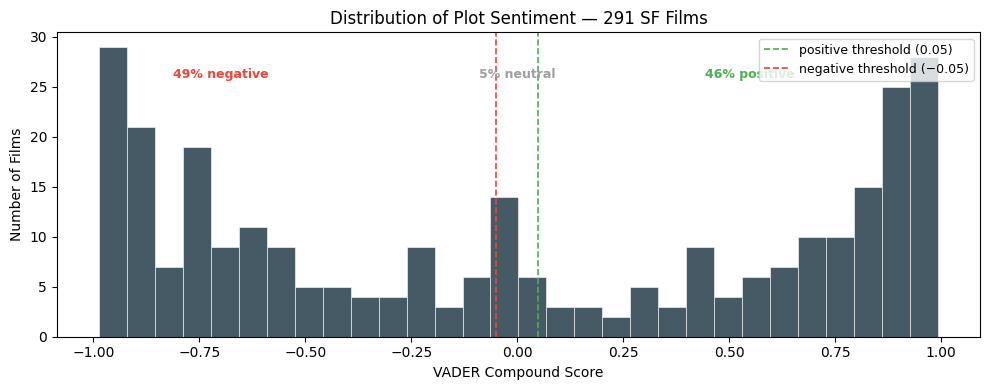

Overall: negative 49%  |  neutral 5%  |  positive 46%


In [ ]:
# Chart 1: Overall sentiment distribution
counts = df["sentiment_label"].value_counts()
total  = counts.sum()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df["compound"].dropna(), bins=30, color="#455A64", edgecolor="white", linewidth=0.4)
ax.axvline( 0.05, color="#4CAF50", linestyle="--", linewidth=1.2, label="positive threshold (0.05)")
ax.axvline(-0.05, color="#F44336", linestyle="--", linewidth=1.2, label="negative threshold (−0.05)")
for label, color, x in [("negative","#F44336",-0.7),("neutral","#9E9E9E",0.0),("positive","#4CAF50",0.55)]:
    ax.text(x, ax.get_ylim()[1]*0.85,
            f"{counts.get(label,0)/total*100:.0f}% {label}",
            color=color, ha="center", fontsize=9, fontweight="bold")
ax.set_xlabel("VADER Compound Score")
ax.set_ylabel("Number of Films")
ax.set_title("Distribution of Plot Sentiment — 291 SF Films")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print("Overall: negative {:.0f}%  |  neutral {:.0f}%  |  positive {:.0f}%".format(
    counts.get("negative",0)/total*100, counts.get("neutral",0)/total*100, counts.get("positive",0)/total*100))

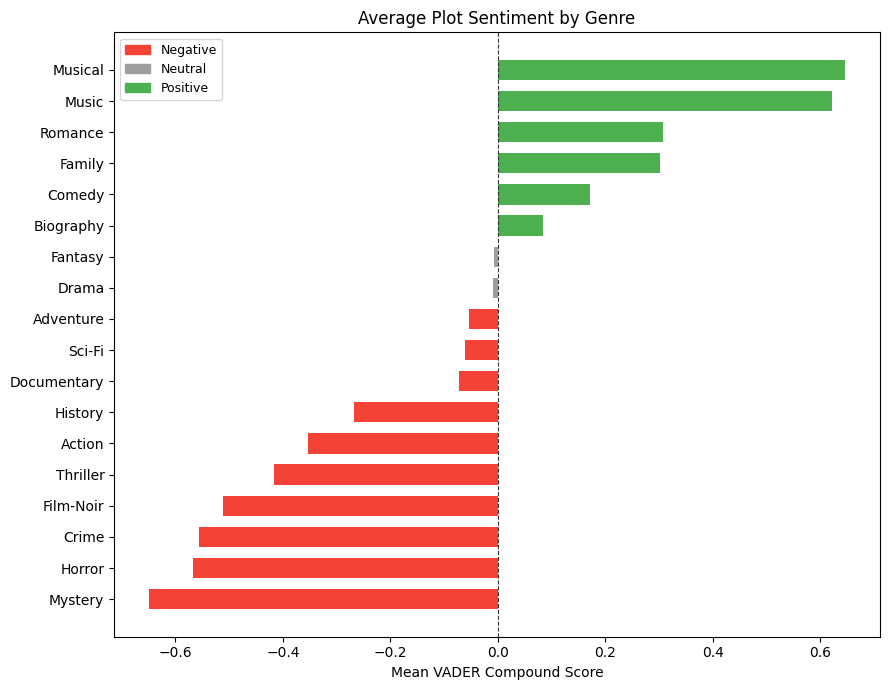

In [ ]:
# Chart 2: Average sentiment by genre
df_exploded = (
    df.dropna(subset=["compound","Genres"])
    .assign(genre=lambda d: d["Genres"].str.split(", "))
    .explode("genre")
    .assign(genre=lambda d: d["genre"].str.strip())
)
genre_stats = (
    df_exploded.groupby("genre")["compound"]
    .agg(mean="mean", count="count")
    .query("count >= 5")
    .sort_values("mean")
    .reset_index()
)
colors = ["#F44336" if m < -0.05 else "#9E9E9E" if m < 0.05 else "#4CAF50"
          for m in genre_stats["mean"]]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(genre_stats["genre"], genre_stats["mean"], color=colors, height=0.65)
ax.axvline(0, color="#333", linewidth=0.8, linestyle="--")
ax.set_xlabel("Mean VADER Compound Score")
ax.set_title("Average Plot Sentiment by Genre")
patches = [mpatches.Patch(color=c, label=l) for c, l in
           [("#F44336","Negative"),("#9E9E9E","Neutral"),("#4CAF50","Positive")]]
ax.legend(handles=patches, fontsize=9)
plt.tight_layout()
plt.show()

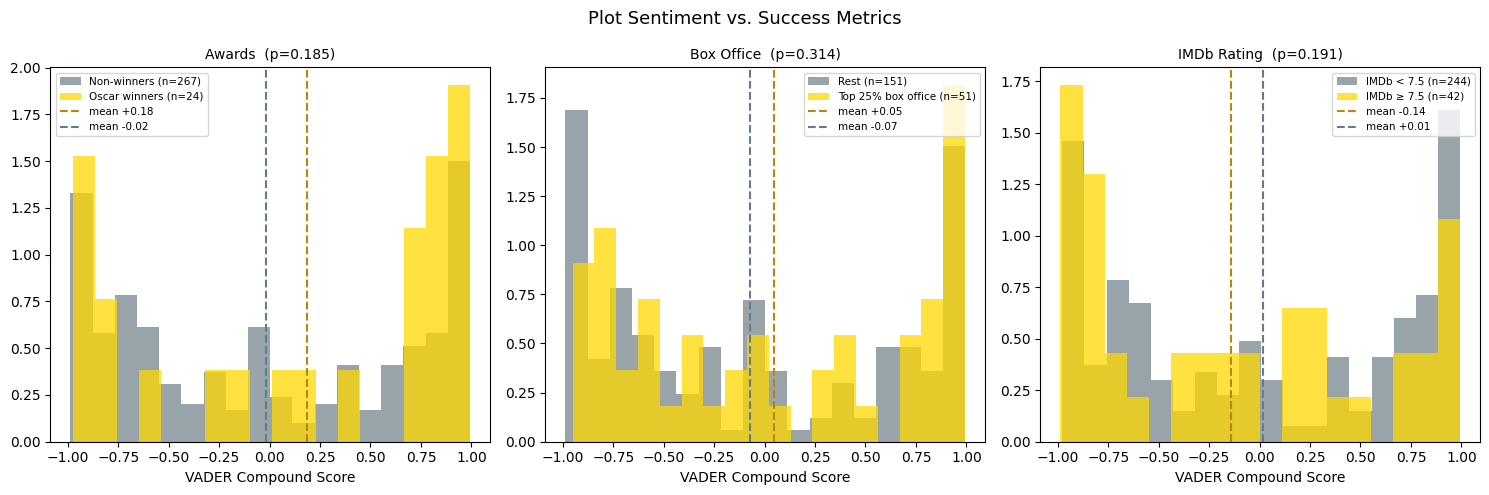

In [ ]:
# Chart 3: Sentiment vs. success metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Plot Sentiment vs. Success Metrics", fontsize=13)

bo_thresh   = df["box_office_num"].quantile(0.75)
comparisons = [
    ("Oscar winners",    df[df["won_oscar"]]["compound"].dropna(),
     "Non-winners",      df[~df["won_oscar"]]["compound"].dropna(),     axes[0], "Awards"),
    ("Top 25% box office", df[df["box_office_num"] >= bo_thresh]["compound"].dropna(),
     "Rest",               df[df["box_office_num"] <  bo_thresh]["compound"].dropna(), axes[1], "Box Office"),
    ("IMDb ≥ 7.5",      df[df["Imdb_rating"] >= 7.5]["compound"].dropna(),
     "IMDb < 7.5",      df[df["Imdb_rating"] <  7.5]["compound"].dropna(),            axes[2], "IMDb Rating"),
]
for label_a, grp_a, label_b, grp_b, ax, title in comparisons:
    ax.hist(grp_b, bins=18, density=True, alpha=0.55, color="#455A64", label=f"{label_b} (n={len(grp_b)})")
    ax.hist(grp_a, bins=18, density=True, alpha=0.75, color="#FFD700", label=f"{label_a} (n={len(grp_a)})")
    ax.axvline(grp_a.mean(), color="#B8860B", linestyle="--", linewidth=1.5,
               label=f"mean {grp_a.mean():+.2f}")
    ax.axvline(grp_b.mean(), color="#607D8B", linestyle="--", linewidth=1.5,
               label=f"mean {grp_b.mean():+.2f}")
    _, p = stats.ttest_ind(grp_a, grp_b)
    ax.set_title(f"{title}  (p={p:.3f})", fontsize=10)
    ax.set_xlabel("VADER Compound Score")
    ax.legend(fontsize=7.5)
plt.tight_layout()
plt.show()

#### Presentation on the website

The analysis produced three insights. The challenge was communicating them to a non-technical reader without introducing statistical jargon. We made three presentation decisions:

**1. The tone slider** (`toneScrolly`) — rather than opening with a histogram, the website shows a single film on a dark-to-uplifting scale. The reader first encounters *Zodiac* at −0.77 (dark), then scrolls to *Dr. Dolittle 2* at +0.43 (uplifting), then to *Babies* near zero (neutral). Only after those three concrete examples does the story move to aggregate patterns. The concrete-before-abstract ordering is what makes the compound score feel intuitive — the reader has already calibrated what −0.77 and +0.43 feel like before being shown a chart full of numbers.

**2. The genre sentiment chart** (`genreFrame`) — the bar chart presents genre-level average sentiment as a horizontal bar chart. The horizontal form was chosen because genre labels are long and horizontal bars are easier to scan for rank than vertical columns. Ordering by score (not alphabetically) makes the emotional spectrum immediately visible — Documentary and Biography cluster at the positive end, Horror at the negative.

**3. The sentiment vs. success histograms** (`sentimentFrame`) — overlapping histograms compare dark vs. uplifting films across three success dimensions: Oscar recognition, box office performance, and IMDb rating. The histogram format was chosen because showing two full distributions is more honest than comparing two means — the groups overlap substantially, and showing only means would overstate the effect. The three comparisons were sequenced to build a narrative: tone matters most for critical recognition (Oscars), less for commercial success (box office), and audiences are the most drawn to darker material (IMDb).


In [ ]:
from IPython.display import IFrame, display

# Genre sentiment bar chart — average VADER compound score per genre
# Source: genreFrame in website_possible_final_2.html
display(IFrame('genre_sentiment_chart.html', width='100%', height=420))


In [ ]:
from IPython.display import IFrame, display

# Sentiment vs. success histograms — dark vs. uplifting across Oscar / box office / IMDb
# Source: sentimentFrame in website_possible_final_2.html
display(IFrame('sentiment_histograms.html', width='100%', height=480))


### 'Now It's Your Turn!' — Final Interactive Map

The website closes by handing control to the reader. A full interactive Leaflet map lets anyone click on any filming location to see the film's title, IMDb rating, box office revenue, and Oscar status in a popup. This is the open-ended exploration phase of the Martini Glass structure — after being guided through the story, the reader is invited to test their own hypotheses.


#### Analysis

> **⚠️ Analysis script missing** 


#### Presentation on the website

Placing a free-exploration map at the end — after the guided narrative — is the defining feature of the Martini Glass structure (Segel & Heer, 2010). The reader arrives at this map having already been shown *what patterns exist* (where films concentrate, how sentiment correlates with success). The map gives them the tools to test those patterns themselves: does the high-box-office cluster really sit in Lone Mountain? Are the Oscar-winning films really where the heat map said they were?

The click-to-reveal popup format was chosen over always-on labels because a map of 316 clickable points would be unreadable if all labels were visible at once. Click-to-reveal rewards exploration without front-loading information — consistent with the 'reader as explorer' framing of this final section.


## Discussion

Reflecting on the project, bringing this data to life provided valuable insights into both the technical and narrative elements of data visualization. 

### What went well?
* **Data Integration:** Integrating geographic information from the San Francisco Open Data portal with the OMDb API was seamless. This approach bridged the gap between basic location data and richer cinematic metrics, such as box office numbers, awards, and IMDb ratings. This gave us a more comprehensive dataset to work with.
* **Scrollytelling Execution:** The Martini Glass narrative structure was highly effective. Beginning with an author-driven, scrollytelling map engaged the user without overwhelming them. This approach paced the introduction of complex variables (geography, time, and success metrics) before transitioning to full interactive control at the conclusion.
* **The Cinematic Aesthetic:** The visual design featuring dark modes, gold accents, and smooth map transitions, effectively captured the movie theme and created an immersive user experience.

### What is still missing?
* **Deeper Qualitative Data:** While our matching process was successful, our analysis relies on the high-level metrics provided by the OMDb API, such as overall ratings and short plot summaries. Having access to deeper, user-generated data (like full text reviews from IMDb) would have allowed for a much more nuanced and accurate sentiment analysis of how audiences actually felt about these films.
* **Granular Sentiment Context:** Although we applied sentiment analysis to movie plots, film emotions are highly subjective. Depending solely on text summaries may overlook nuanced tones present in the actual films, such as comedies with dark or violent premises.

### What could be improved? Why?
* **Mobile Responsiveness:** The current interactive maps and scrollytelling elements are optimized for desktop viewing. Enhancing the mobile layout would make the story accessible to a broader audience, as complex map visualizations can be challenging to navigate on smaller screens.
* **More Interactivity in Early Stages:** While the Martini Glass structure effectively guides the user, adding interactive elements, such as hovering over a decade to reveal the top film during the introduction, could further engage users before the final exploration stage.
* **Expanded Definition of Success:** We defined "success" using box office performance, Oscars, and IMDb ratings. Incorporating a metric such as "Return on Investment" (budget versus box office) could provide a more accurate perspective on commercial success, as high box office gross does not always indicate high profitability.

## Contributions

We have started by brainstorming together and setting up the structure of the website.
Then we have split the analysis in the following way:
* Introduction - Hinojosa, Omar González (s) & Babeii, Denisa (s253528)
* 'San Francisco on screen' - Hinojosa, Omar González (s)
* Maps section - Babeii, Denisa (s253528)
* 'Looking beyond location' - Ilves, Ursula (s) - analysis, Hinojosa, Omar González (s) - infographics & text, Babeii, Denisa (s253528) - text
* 'What does this tell us?' - Hinojosa, Omar González (s) & Babeii, Denisa (s253528)
* 'Now it's your turn!' - Hinojosa, Omar González (s)
* Notebook parts 1-3 - Hinojosa, Omar González (s)
* Notebook part 4 - Babeii, Denisa (s253528)
* Notebook part 5 - Ilves, Ursula (s), Hinojosa, Omar González (s), Babeii, Denisa (s253528)
* Notebook part 6 - Ilves, Ursula (s)

## References

<div id="references">
  <p style="font-weight:600;">Sites</p>
  <p id="ref1">[1] San Francisco Open Data Portal. (2026). Film Locations in San Francisco. Retrieved from <a href="https://data.sfgov.org/Culture-and-Recreation/Film-Locations-in-San-Francisco/yitu-d5am/about_data" target="_blank">https://data.sfgov.org/Culture-and-Recreation/Film-Locations-in-San-Francisco/yitu-d5am/about_data</a></p>
  <p id="ref2">[2] Open Movie Database (OMDb) API. (2026). Retrieved from <a href="https://www.omdbapi.com/" target="_blank">https://www.omdbapi.com/</a></p>
  <p id="ref3">[3] San Francisco Open Data Portal. (2026). SF Find Neighborhoods. Retrieved from <a href="https://data.sfgov.org/-/SF-Find-Neighborhoods/pty2-tcw4" target="_blank">https://data.sfgov.org/-/SF-Find-Neighborhoods/pty2-tcw4</a></p>
</div>